# Analyza dat – Spotify datasety

Tento notebook obsahuje zakladni analyzu tri datovych souboru pouzitych v semestralnim projektu ELK Stack.

**Datasety:**
- `tracks_clean.csv` – skladby s audio features (15 000 radku)
- `artists_clean.csv` – interpreti s zanry a followery (5 271 radku)
- `charts_clean.csv` – Spotify zebrickovy podle regionu a data (8 000 radku)

**Zdroj dat:**
- Tracks: https://www.kaggle.com/datasets/maharshipandya/spotify-tracks-dataset
- Artists: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs
- Charts: https://www.kaggle.com/datasets/dhruvildave/spotify-charts

Originalni datasety obsahovaly statisice zaznamu. Pro ucely semestralni prace byly oriznuty na zvladnutelnou velikost.

**Nastroje:** Python 3, Pandas, NumPy, Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Nacteni datasetu
tracks = pd.read_csv("tracks_clean.csv")
artists = pd.read_csv("artists_clean.csv")
charts = pd.read_csv("charts_clean.csv")

print(f"Tracks:  {tracks.shape[0]:>6} radku, {tracks.shape[1]} sloupcu")
print(f"Artists: {artists.shape[0]:>6} radku, {artists.shape[1]} sloupcu")
print(f"Charts:  {charts.shape[0]:>6} radku, {charts.shape[1]} sloupcu")
print(f"\nCelkem:  {tracks.shape[0] + artists.shape[0] + charts.shape[0]:>6} zaznamu")

Tracks:   15000 radku, 20 sloupcu
Artists:   5271 radku, 7 sloupcu
Charts:    8000 radku, 8 sloupcu

Celkem:   28271 zaznamu


---
## 1. Tracks – skladby (tracks_clean.csv)

Dataset obsahuje 15 000 skladeb se Spotify audio features. Kazda skladba ma 20 atributu vcetne popularity, tanecnosti, energie, tempa a zanru.

In [2]:
# Struktura datasetu
print("=== SLOUPCE A DATOVE TYPY ===")
print(tracks.dtypes.to_string())
print(f"\n=== PRVNICH 5 RADKU ===")
tracks.head()

=== SLOUPCE A DATOVE TYPY ===
track_id             object
track_name           object
artists              object
album_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object

=== PRVNICH 5 RADKU ===


,track_id,track_name,artists,album_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5MAK1nd8R6PWnle1Q1WJvh,I See Red,Everybody Loves an Outlaw,I See Red,77,230613,False,0.509,0.448,4,-7.552,0,0.0357,0.00713,0.013700,0.2440,0.221,156.909,3,blues
1,2tznHmp70DxMyr2XhWLOW0,Cigarette Daydreams,Cage The Elephant,Melophobia,79,208760,False,0.636,0.676,2,-3.442,1,0.0263,0.08070,0.000000,0.0831,0.273,113.980,4,blues
2,7vguMCv8uVuZLiQJ156u3Z,Play with Fire (feat. Yacht Money),Sam Tinnesz;Yacht Money,Play with Fire (feat. Yacht Money),76,180690,False,0.573,0.539,2,-6.091,0,0.0322,0.01620,0.000012,0.1050,0.390,75.012,4,blues
3,3dPQuX8Gs42Y7b454ybpMR,Seven Nation Army,The White Stripes,Elephant,84,232106,False,0.743,0.446,4,-7.807,0,0.0683,0.00390,0.118000,0.3370,0.278,123.596,4,blues
4,6zC0mpGYwbNTpk9SKwh08f,Wonderful Tonight,Eric Clapton,Slowhand 35th Anniversary (Super Deluxe),76,225026,False,0.572,0.214,7,-15.625,1,0.0293,0.64900,0.129000,0.1250,0.485,95.542,4,blues


In [3]:
# Prazdne (chybejici) hodnoty
print("=== PRAZDNE HODNOTY ===")
null_counts = tracks.isnull().sum()
null_pct = (null_counts / len(tracks) * 100).round(2)
null_df = pd.DataFrame({"chybejici": null_counts, "procent": null_pct})
print(null_df[null_df["chybejici"] > 0].to_string() if null_df["chybejici"].sum() > 0 else "Zadne prazdne hodnoty – dataset je kompletni.")

=== PRAZDNE HODNOTY ===
Zadne prazdne hodnoty – dataset je kompletni.


In [4]:
# Zakladni statistiky ciselnych poli
print("=== DESKRIPTIVNI STATISTIKY ===")
tracks[["popularity", "duration_ms", "danceability", "energy", "loudness",
        "speechiness", "acousticness", "instrumentalness", "liveness",
        "valence", "tempo"]].describe().round(3)

=== DESKRIPTIVNI STATISTIKY ===


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000
mean,29.553,223633.159,0.596,0.610,-8.169,0.074,0.338,0.086,0.185,0.530,119.950
std,29.471,97031.494,0.164,0.240,4.966,0.073,0.329,0.237,0.153,0.248,30.181
min,0.000,17453.000,0.000,0.000,-41.531,0.000,0.000,0.000,0.015,0.000,0.000
25%,0.000,178158.750,0.486,0.458,-9.661,0.035,0.045,0.000,0.095,0.332,95.063
50%,32.000,210915.000,0.608,0.649,-6.880,0.047,0.207,0.000,0.124,0.536,118.536
75%,57.000,250000.000,0.721,0.802,-5.004,0.078,0.617,0.003,0.234,0.727,139.836
max,100.000,2959346.000,0.975,1.000,1.023,0.924,0.996,0.984,0.989,0.994,243.372


In [5]:
# Unikatni hodnoty klicovych poli
print(f"Unikatnich track_id:   {tracks['track_id'].nunique():>6}  (z {len(tracks)} radku → {len(tracks) - tracks['track_id'].nunique()} duplicit)")
print(f"Unikatnich nazvu:      {tracks['track_name'].nunique():>6}")
print(f"Unikatnich interpretu: {tracks['artists'].nunique():>6}")
print(f"Unikatnich alb:        {tracks['album_name'].nunique():>6}")
print(f"Zanru:                 {tracks['track_genre'].nunique():>6}")
print(f"\nExplicit skladby: {tracks['explicit'].value_counts().to_dict()}")
print(f"Mode (0=minor, 1=major): {tracks['mode'].value_counts().to_dict()}")

Unikatnich track_id:    13119  (z 15000 radku → 1881 duplicit)
Unikatnich nazvu:        9562
Unikatnich interpretu:   5065
Unikatnich alb:          6154
Zanru:                     15

Explicit skladby: {False: 13771, True: 1229}
Mode (0=minor, 1=major): {1: 9869, 0: 5131}


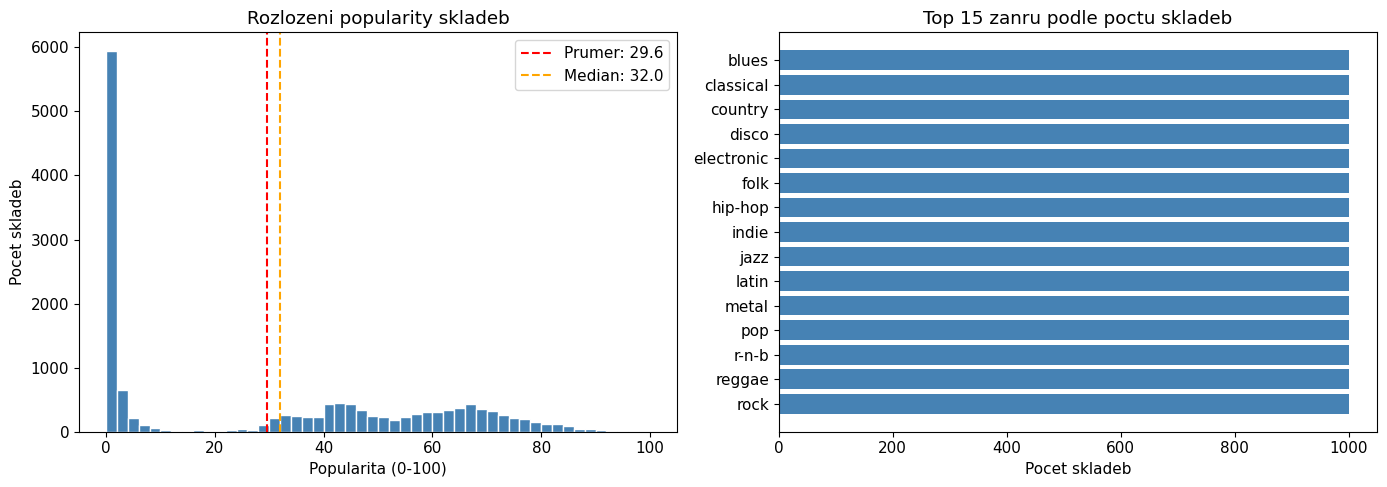

Ulozeno: graf_tracks_popularita_zanry.png


In [6]:
# Graf 1: Rozlozeni popularity skladeb
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tracks["popularity"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Rozlozeni popularity skladeb")
axes[0].set_xlabel("Popularita (0-100)")
axes[0].set_ylabel("Pocet skladeb")
axes[0].axvline(tracks["popularity"].mean(), color="red", linestyle="--", label=f"Prumer: {tracks['popularity'].mean():.1f}")
axes[0].axvline(tracks["popularity"].median(), color="orange", linestyle="--", label=f"Median: {tracks['popularity'].median():.1f}")
axes[0].legend()

# Graf 2: Top 15 zanru podle poctu skladeb
genre_counts = tracks["track_genre"].value_counts().head(15)
axes[1].barh(genre_counts.index[::-1], genre_counts.values[::-1], color="steelblue")
axes[1].set_title("Top 15 zanru podle poctu skladeb")
axes[1].set_xlabel("Pocet skladeb")

plt.tight_layout()
plt.savefig("graf_tracks_popularita_zanry.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: graf_tracks_popularita_zanry.png")

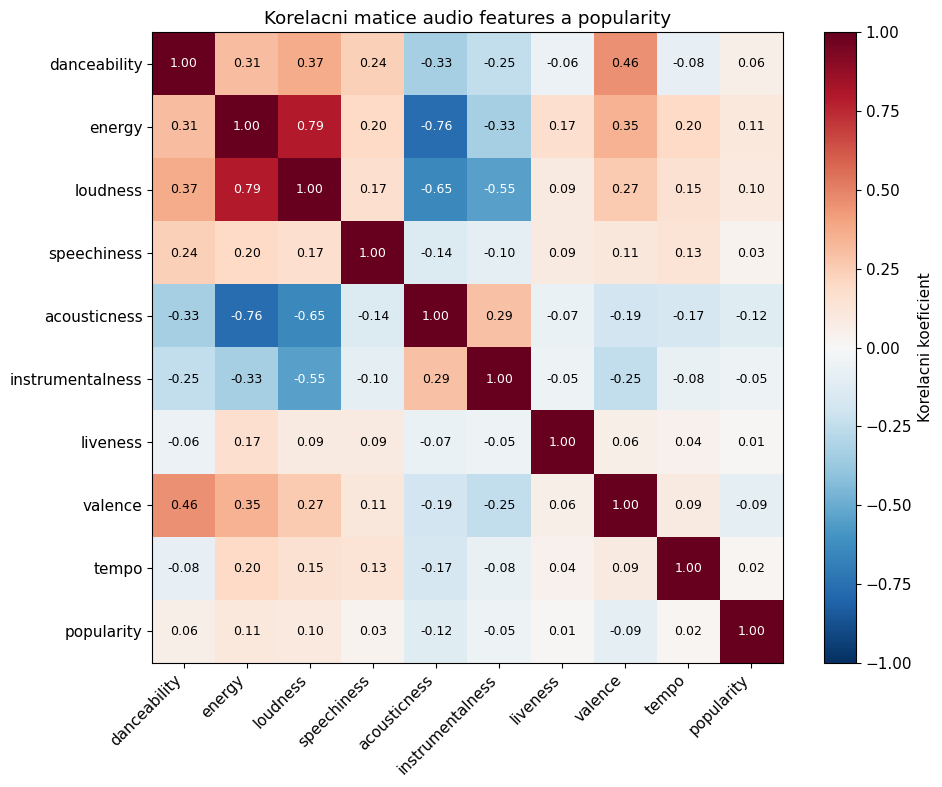

Ulozeno: graf_tracks_korelace.png


In [7]:
# Graf 3: Korelace audio features
audio_features = ["danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

corr = tracks[audio_features + ["popularity"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=9)
plt.colorbar(im, label="Korelacni koeficient")
plt.title("Korelacni matice audio features a popularity")
plt.tight_layout()
plt.savefig("graf_tracks_korelace.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: graf_tracks_korelace.png")

---
## 2. Artists – interpreti (artists_clean.csv)

Dataset obsahuje 5 271 interpretu. Kazdy ma pocet followeru, zanry (jako seznam), popularitu a propojeni na related artists.

In [8]:
# Struktura a prazdne hodnoty
print("=== SLOUPCE A DATOVE TYPY ===")
print(artists.dtypes.to_string())
print(f"\n=== PRAZDNE HODNOTY ===")
null_a = artists.isnull().sum()
for col in null_a[null_a > 0].index:
    print(f"  {col}: {null_a[col]} ({null_a[col]/len(artists)*100:.1f}%)")
if null_a.sum() == 0:
    print("  Zadne prazdne hodnoty.")

print(f"\n=== ZAKLADNI UDAJE ===")
print(f"Unikatnich interpretu: {artists['id'].nunique()}")
print(f"Followers – min: {artists['followers'].min():.0f}, max: {artists['followers'].max():.0f}, prumer: {artists['followers'].mean():.0f}, median: {artists['followers'].median():.0f}")
print(f"Popularita – min: {artists['popularity'].min()}, max: {artists['popularity'].max()}, prumer: {artists['popularity'].mean():.1f}")
print(f"\n=== PRVNICH 5 RADKU ===")
artists.head()

=== SLOUPCE A DATOVE TYPY ===
id                        object
name                      object
followers                float64
genres                    object
popularity                 int64
related_artists_count      int64
related_artists_ids       object

=== PRAZDNE HODNOTY ===
  related_artists_ids: 869 (16.5%)

=== ZAKLADNI UDAJE ===
Unikatnich interpretu: 5271
Followers – min: 0, max: 78900234, prumer: 905748, median: 51246
Popularita – min: 0, max: 100, prumer: 50.6

=== PRVNICH 5 RADKU ===


,id,name,followers,genres,popularity,related_artists_count,related_artists_ids
0,7frYUe4C7A42uZqCzD34Y4,Sultaan,53636.0,"['desi pop', 'punjabi hip hop', 'punjabi pop']",53,20,58o8gC55d5XSsI2MlTZ3M5;2MUxB7dxsGn3ytMPyyekmj;...
1,72578usTM6Cj5qWsi471Nc,Raghu Dixit,248568.0,"['filmi', 'indian folk', 'indian rock', 'kanna...",52,20,0Xbdgzdm7k9BJ5gUgmAkpy;4oVMLzAqW6qhRpZWt8fNw4;...
2,7b6Ui7JVaBDEfZB9k6nHL0,The Local Train,701766.0,"['desi pop', 'hindi indie', 'indian indie', 'i...",57,20,04hYGGSjYtLekuuJXEGrIl;6xlrAAgxcRlgCXnbg2hcFc;...
3,4bvGDTEPFnllKiJaEZGuXk,Achint,6395.0,['indian folk'],49,20,2AWF4fUAstzXyJd01JTuS3;3mzZ5nf3QScPqc7y9EzJ6X;...
4,5wJ1H6ud777odtZl5gG507,Vishal Mishra,211174.0,"['desi pop', 'modern bollywood']",66,20,6RF8hEdlUKoLPQOHmBbHiM;3TOhzLRYnkkul71yRBxIoM;...


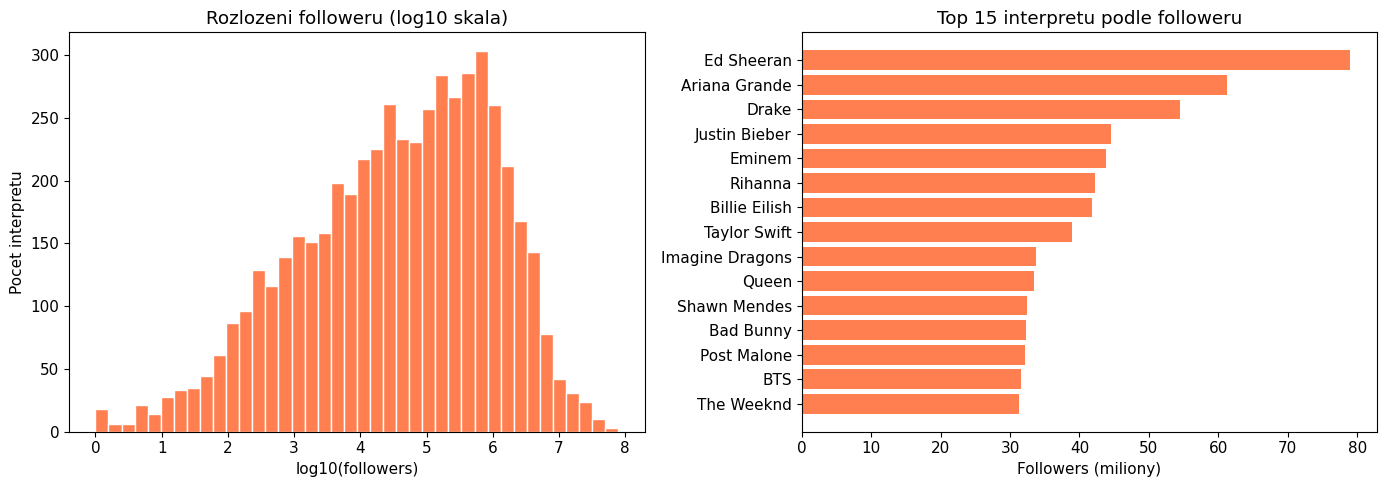

Ulozeno: graf_artists_followers.png


In [9]:
# Graf 4: Rozlozeni followeru (logaritmicka skala) a Top 15 interpretu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Followers histogram (log scale)
followers_nonzero = artists["followers"].dropna()
followers_nonzero = followers_nonzero[followers_nonzero > 0]
axes[0].hist(np.log10(followers_nonzero), bins=40, color="coral", edgecolor="white")
axes[0].set_title("Rozlozeni followeru (log10 skala)")
axes[0].set_xlabel("log10(followers)")
axes[0].set_ylabel("Pocet interpretu")

# Top 15 interpretu podle followeru
top_artists = artists.nlargest(15, "followers")[["name", "followers"]].sort_values("followers")
axes[1].barh(top_artists["name"], top_artists["followers"] / 1e6, color="coral")
axes[1].set_title("Top 15 interpretu podle followeru")
axes[1].set_xlabel("Followers (miliony)")

plt.tight_layout()
plt.savefig("graf_artists_followers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: graf_artists_followers.png")

In [10]:
# Analyza zanru – kolik zanru ma prumerny interpret, nejcastejsi zanry
import ast

def parse_genres(genre_str):
    """Rozparsuje string '["pop", "rock"]' na list."""
    try:
        return ast.literal_eval(genre_str)
    except:
        return []

artists["genres_list"] = artists["genres"].apply(parse_genres)
artists["genres_count"] = artists["genres_list"].apply(len)

print(f"Prumerny pocet zanru na interpreta: {artists['genres_count'].mean():.1f}")
print(f"Interpreti bez zanru: {(artists['genres_count'] == 0).sum()} ({(artists['genres_count'] == 0).mean()*100:.1f}%)")

# Exploze zanru – kazdy zanr jako samostatny radek
all_genres = artists["genres_list"].explode()
all_genres = all_genres[all_genres.notna() & (all_genres != "")]
print(f"\nCelkem unikatnich zanru: {all_genres.nunique()}")
print(f"\nTop 20 nejcastejsich zanru:")
print(all_genres.value_counts().head(20).to_string())

Prumerny pocet zanru na interpreta: 3.0
Interpreti bez zanru: 986 (18.7%)

Celkem unikatnich zanru: 1874

Top 20 nejcastejsich zanru:
genres_list
rock                     269
pop                      217
desi pop                 186
filmi                    160
latin                    156
classic rock             154
dance pop                152
modern bollywood         148
soft rock                138
mellow gold              136
album rock               128
trap latino              121
edm                      120
modern rock              119
alternative metal        117
adult standards          116
disco                    116
classical performance    116
soul                     114
hard rock                113


---
## 3. Charts – zebrickovy (charts_clean.csv)

Dataset obsahuje 8 000 zaznamu ze Spotify zebricku (top200, viral50) z ruznych regionu a dat.

In [11]:
# Struktura a prazdne hodnoty
print("=== SLOUPCE A DATOVE TYPY ===")
print(charts.dtypes.to_string())
print(f"\n=== PRAZDNE HODNOTY ===")
null_c = charts.isnull().sum()
for col in null_c[null_c > 0].index:
    print(f"  {col}: {null_c[col]} ({null_c[col]/len(charts)*100:.1f}%)")
if null_c.sum() == 0:
    print("  Zadne prazdne hodnoty.")

print(f"\n=== ZAKLADNI UDAJE ===")
print(f"Casovy rozsah: {charts['date'].min()} az {charts['date'].max()}")
print(f"Regiony: {charts['region'].nunique()} ({', '.join(charts['region'].unique()[:10])}{'...' if charts['region'].nunique() > 10 else ''})")
print(f"Typy zebricku: {charts['chart'].unique().tolist()}")
print(f"Trendy: {charts['trend'].value_counts().to_dict()}")
print(f"Streams – min: {charts['streams'].min()}, max: {charts['streams'].max():,}, prumer: {charts['streams'].mean():,.0f}")
print(f"\n=== PRVNICH 5 RADKU ===")
charts.head()

=== SLOUPCE A DATOVE TYPY ===
title       object
rank         int64
date        object
artist      object
region      object
chart       object
trend       object
streams    float64

=== PRAZDNE HODNOTY ===
  streams: 352 (4.4%)

=== ZAKLADNI UDAJE ===
Casovy rozsah: 2017-01-01 az 2020-05-01
Regiony: 6 (Czech Republic, France, Germany, Global, United Kingdom, United States)
Typy zebricku: ['top200', 'viral50']
Trendy: {'MOVE_DOWN': 3362, 'MOVE_UP': 3186, 'SAME_POSITION': 843, 'NEW_ENTRY': 609}
Streams – min: 1001.0, max: 7,817,732.0, prumer: 244,857

=== PRVNICH 5 RADKU ===


,title,rank,date,artist,region,chart,trend,streams
0,Closer,1,2017-01-01,"The Chainsmokers, Halsey",Czech Republic,top200,SAME_POSITION,6406.0
1,Starboy,2,2017-01-01,"The Weeknd, Daft Punk",Czech Republic,top200,MOVE_UP,6165.0
2,Let Me Love You,3,2017-01-01,"DJ Snake, Justin Bieber",Czech Republic,top200,MOVE_DOWN,6040.0
3,Rockabye (feat. Sean Paul & Anne-Marie),4,2017-01-01,Clean Bandit,Czech Republic,top200,SAME_POSITION,5416.0
4,Don't Wanna Know,5,2017-01-01,"Maroon 5, Kendrick Lamar",Czech Republic,top200,MOVE_UP,4865.0


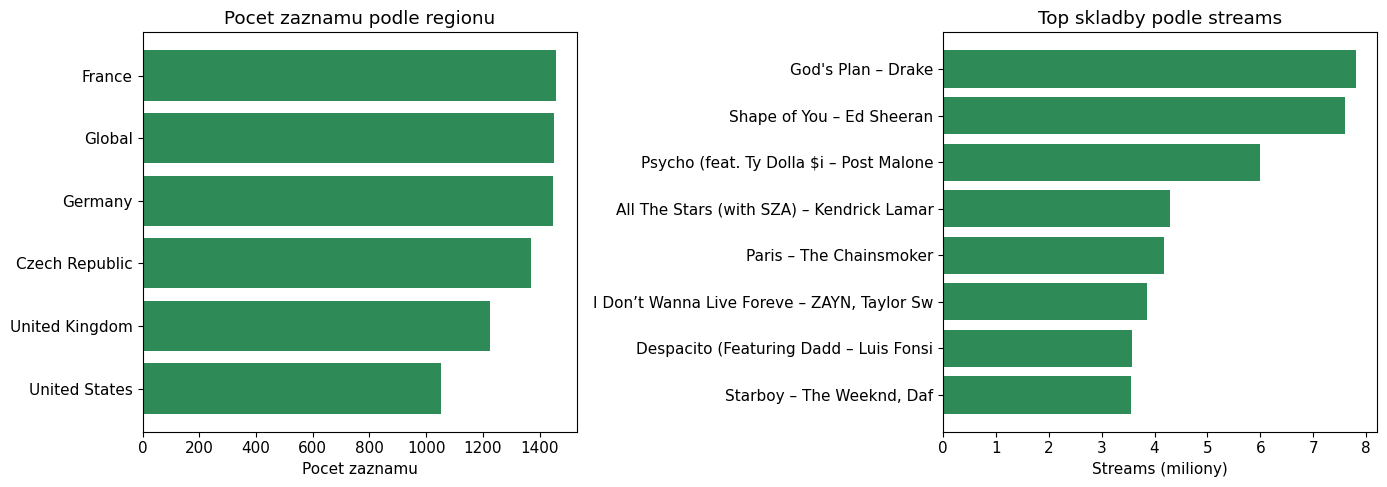

Ulozeno: graf_charts_regiony_streams.png


In [12]:
# Graf 5: Pocet zaznamu podle regionu a zebricku
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regiony
region_counts = charts["region"].value_counts()
axes[0].barh(region_counts.index[::-1], region_counts.values[::-1], color="seagreen")
axes[0].set_title("Pocet zaznamu podle regionu")
axes[0].set_xlabel("Pocet zaznamu")

# Top 15 skladeb podle streams
top_streams = charts.nlargest(15, "streams")[["title", "artist", "streams"]].drop_duplicates("title")
top_streams = top_streams.sort_values("streams")
labels = [f"{r['title'][:25]} – {r['artist'][:15]}" for _, r in top_streams.iterrows()]
axes[1].barh(labels, top_streams["streams"] / 1e6, color="seagreen")
axes[1].set_title("Top skladby podle streams")
axes[1].set_xlabel("Streams (miliony)")

plt.tight_layout()
plt.savefig("graf_charts_regiony_streams.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ulozeno: graf_charts_regiony_streams.png")

---
## 4. Shrnuti a upravy dat

### Provedene upravy
- **Orizhnuti**: Originalni datasety z Kaggle obsahovaly statisice zaznamu. Pro ucely semestralni prace byly oriznuty na zvladnutelnou velikost (tracks: 15 000, artists: 5 271, charts: 8 000).
- **Cisteni**: Datasety byly predzpracovany – odstranen BOM, overena konzistence sloupcu.
- **Zadne anonymizace**: Data jsou verejna (Spotify API), anonymizace neni potreba.

### Proc tyto datasety
- Tri propojitelne soubory o jednom tematu (hudba/streaming) – splnuje pozadavek zadani.
- Tracks obsahuje 15 000 zaznamu – splnuje pozadavek "alespon 5 000".
- Data obsahuji mix ciselnych (audio features), textovych (nazvy, zanry) a datumovych (charts) poli – vhodne pro demonstraci ruznych typu ES dotazu.
- Realna data z praxe (Spotify) – relevantni pro pripadove studie.

### Proc ne jine datove zdroje
- CSV format je nativne podporovan Logstash file inputem.
- Spotify data jsou dobre zdokumentovana a srozumitelna.
- Alternativni zdroje (logy, syslog, Kafka) by vyzadovaly slozitejsi infrastrukturu bez pridane hodnoty pro ucely semestralni prace.

In [13]:
# Souhrnna tabulka vsech datasetu
summary = pd.DataFrame({
    "Dataset": ["tracks_clean.csv", "artists_clean.csv", "charts_clean.csv"],
    "Radku": [len(tracks), len(artists), len(charts)],
    "Sloupcu": [tracks.shape[1], artists.shape[1], charts.shape[1]],
    "Prazdnych hodnot": [tracks.isnull().sum().sum(), artists.isnull().sum().sum(), charts.isnull().sum().sum()],
    "Unikatnich ID": [tracks["track_id"].nunique(), artists["id"].nunique(), "N/A (kompozitni)"],
    "Velikost souboru": [
        f"{tracks.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB",
        f"{artists.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB",
        f"{charts.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB"
    ]
})
print("=== SOUHRNNA TABULKA ===")
summary

=== SOUHRNNA TABULKA ===


,Dataset,Radku,Sloupcu,Prazdnych hodnot,Unikatnich ID,Velikost souboru
0,tracks_clean.csv,15000,20,0,13119,6.5 MB
1,artists_clean.csv,5271,9,869,5271,2.6 MB
2,charts_clean.csv,8000,8,352,N/A (kompozitni),2.9 MB
